# House Price Prediction using Machine Learning

In this project, I explored a housing dataset to understand what factors influence house prices and built a machine learning model to predict them.
The goal was not just to build a model, but to go through the complete process — data cleaning, exploration, feature selection, and evaluation — to understand how real-world ML problems are solved.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
df = pd.read_csv("../data/house_train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [39]:
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

## Data Overview

The dataset contains multiple features related to houses such as quality, size, and year built.
Some columns may have missing values, which we will handle later.

In [40]:
corr = df.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

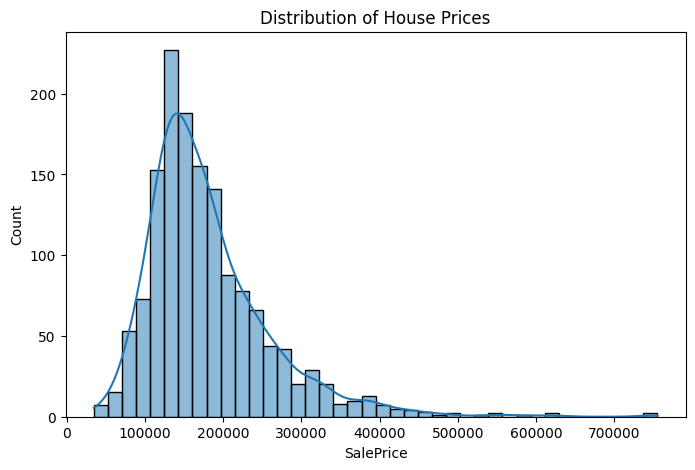

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=40, kde=True)
plt.title("Distribution of House Prices")
plt.show()

## Price Distribution

The distribution of house prices is right-skewed.
This means most houses have lower prices, while a few houses are very expensive.
To improve model performance, we apply log transformation.

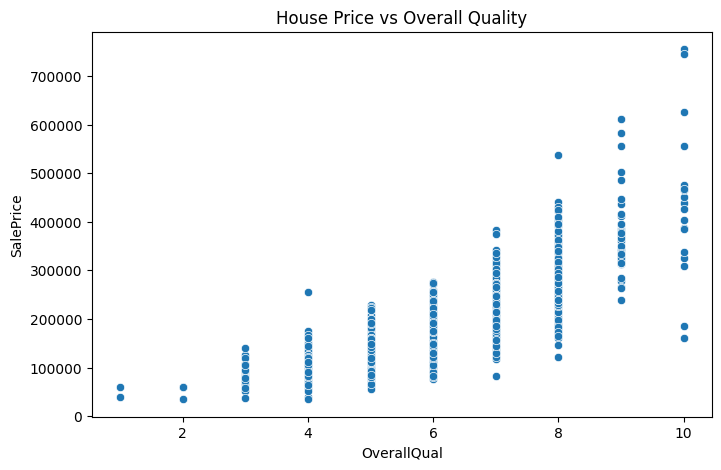

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="OverallQual", y="SalePrice", data=df)
plt.title("House Price vs Overall Quality")
plt.show()

Higher quality houses have higher prices.

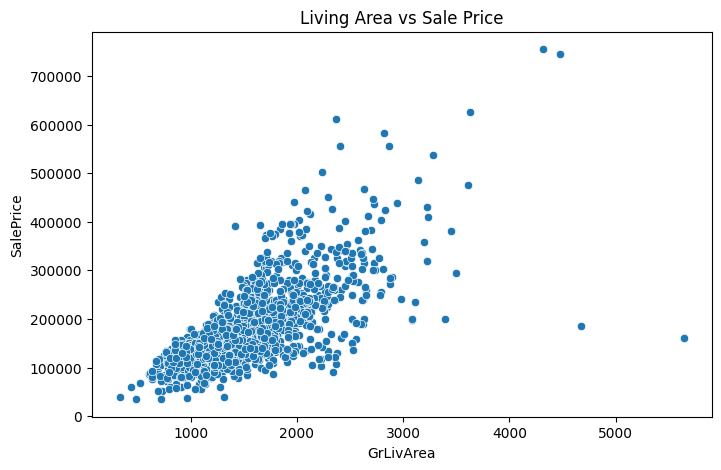

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.title("Living Area vs Sale Price")
plt.show()

## Outlier Detection

Some houses have very large living areas but low prices.
These are outliers and can negatively affect the model, so we remove them.

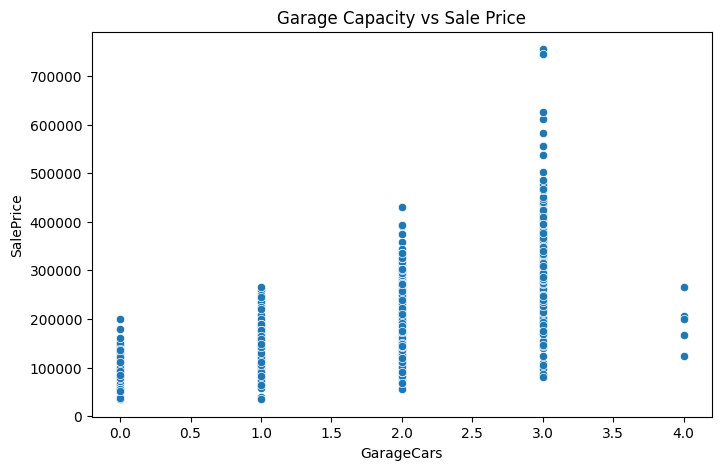

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="GarageCars", y="SalePrice", data=df)
plt.title("Garage Capacity vs Sale Price")
plt.show()

Houses with larger garages generally tend to have higher prices.
However, there are some exceptions where houses with large garages still have lower prices, which suggests that garage size alone does not determine the price and other factors like quality and location also matter.

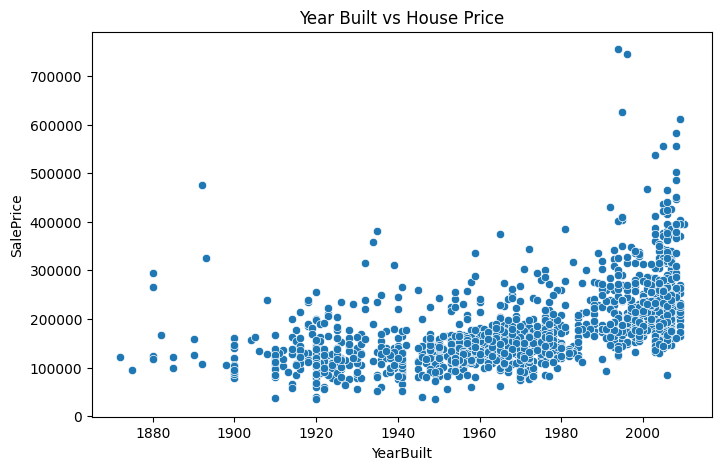

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="YearBuilt", y="SalePrice", data=df)
plt.title("Year Built vs House Price")
plt.show()

Newer houses tend to have slightly higher prices compared to older ones.
However, the relationship is not very strong, which means that the age of the house is not the most important factor in determining price.

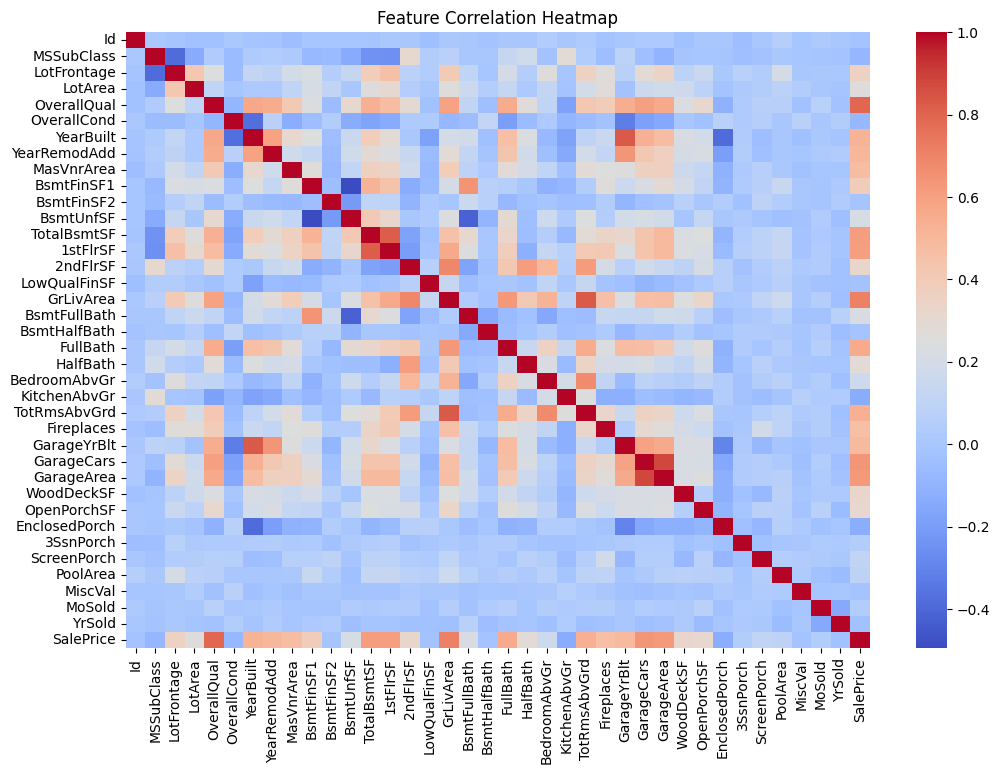

In [46]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Correlation Analysis

The heatmap shows how different features are related to house price.
OverallQual has the strongest correlation with SalePrice, followed by features like GrLivArea and GarageCars.
This helps in selecting important features for the model.

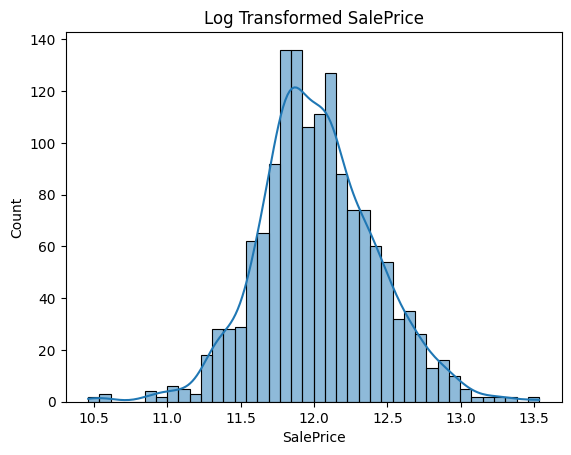

In [48]:
import numpy as np
df["SalePrice"] = np.log(df["SalePrice"])
sns.histplot(df["SalePrice"], bins=40, kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

## Log Transformation

Log transformation helps make the data more balanced and improves model performance.

In [49]:
df = df[df["GrLivArea"] < 4000]

## Removing Outliers

Extreme outliers were removed to improve model accuracy.

In [50]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]

## Feature Selection

Instead of using all features, we select important ones that affect house prices:
- OverallQual
- GrLivArea
- GarageCars
- TotalBsmtSF
- FullBath
- YearBuilt

In [51]:
X = df[features]
y = df["SalePrice"]

In [52]:
X = X.fillna(X.median())

## Train-Test Split

The dataset is split into training and testing sets.
This helps evaluate how well the model performs on unseen data.

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

We use Linear Regression to predict house prices based on selected features.

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [55]:
y_pred = model.predict(X_test)

/Users/shahavi604/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shahavi604/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shahavi604/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [56]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.16806919334010753
R2 Score: 0.8211527321686125


## Model Evaluation

The model is evaluated using RMSE and R² score.
The results show that the model performs reasonably well.

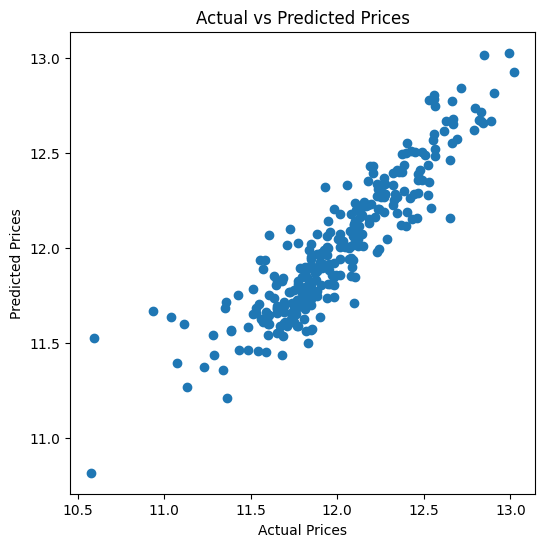

In [57]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [58]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,OverallQual,0.093223
1,GrLivArea,0.000319
2,GarageCars,0.069057
3,TotalBsmtSF,0.000182
4,FullBath,-0.041986
5,YearBuilt,0.002650


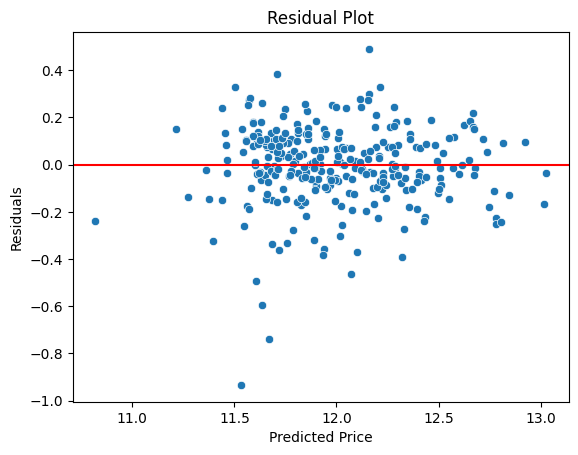

In [59]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Residual Analysis

The residuals are randomly distributed around zero, which means the model is performing well.

## Conclusion

In this project, we built a model to predict house prices.
We performed data cleaning, removed outliers, selected important features, and trained a Linear Regression model.
This project helped in understanding the complete machine learning workflow.